In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [7]:
df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])

In [10]:
df.columns=['class_label','alcohol','malic_acid']

In [11]:
df.sample(5)

,class_label,alcohol,malic_acid
21,1,14.06,1.63
118,2,12.42,1.61
90,2,12.08,1.33
44,1,13.24,3.98
76,2,11.66,1.88


In [28]:
df.shape
print(df['alcohol'].dtype)
df['malic_acid'] = pd.to_numeric(df['malic_acid'], errors='coerce')
df['alcohol'] = pd.to_numeric(df['alcohol'], errors='coerce')
df['class_label']=pd.to_numeric(df['class_label'], errors='coerce')
print(df['class_label'].dtype)


float64
float64


<Axes: xlabel='malic_acid', ylabel='Density'>

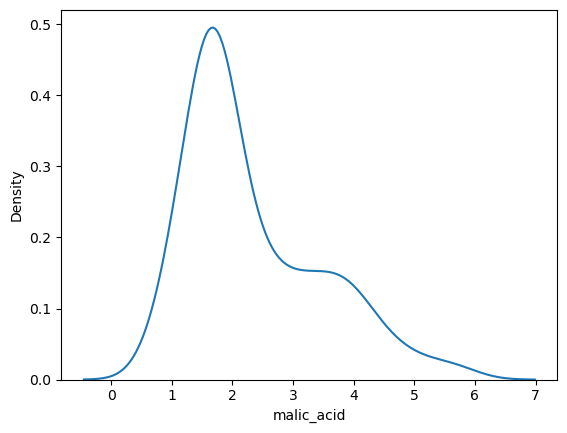

In [22]:
sns.kdeplot(df['malic_acid'])

<Axes: xlabel='alcohol', ylabel='Density'>

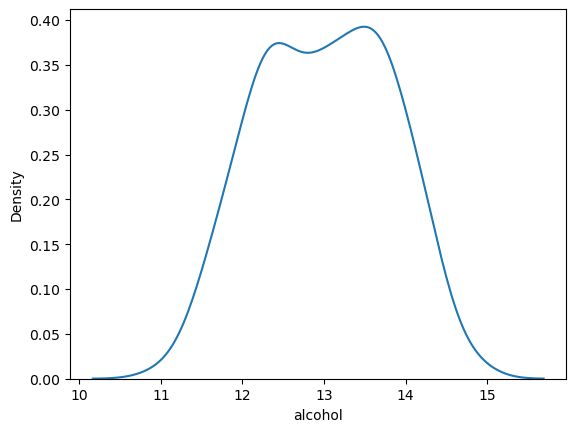

In [23]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='alcohol', ylabel='malic_acid'>

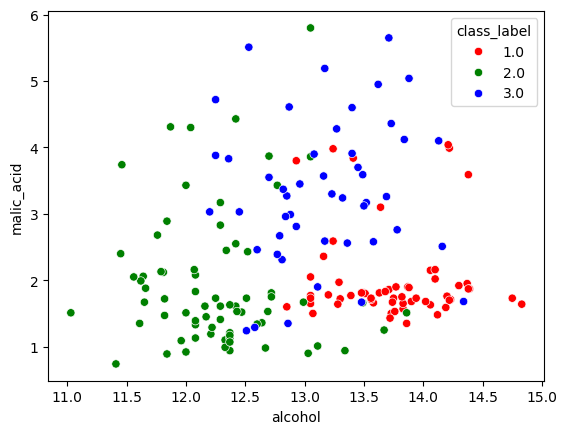

In [29]:
color={1:'red',2:'green',3:'blue'}
sns.scatterplot(x=df['alcohol'],y=df['malic_acid'],hue=df['class_label'],palette=color)

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('class_label',axis=1),df['class_label'],test_size=0.25,random_state=0)

In [32]:
x_train.shape,x_test.shape

((134, 2), (45, 2))

In [33]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
scaler=MinMaxScaler()

In [38]:
# fit the scaler to the train set, it will learn the parameter

scaler.fit(x_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [40]:
#fit only training data per karoge but transform training and test dono ko karoge

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [42]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [43]:
x_train_scaled.sample(6)

,alcohol,malic_acid
111,0.276316,0.132383
92,0.468421,0.319756
130,0.547368,0.054990
88,0.486842,0.458248
3,0.313158,0.112016
98,0.100000,0.000000


In [44]:
np.round(x_train.describe(),1)

,alcohol,malic_acid
count,133.0,133.0
mean,13.0,2.3
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.5
50%,13.0,1.8
75%,13.7,3.0
max,14.8,5.6


In [45]:
np.round(x_train_scaled.describe(),1)

,alcohol,malic_acid
count,133.0,133.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'after scalling')

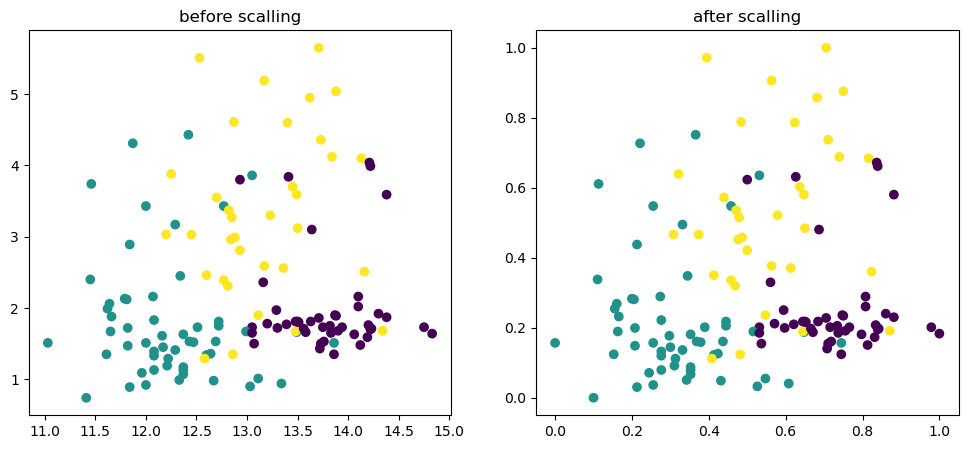

In [51]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['alcohol'],x_train['malic_acid'],c=y_train)
ax1.set_title('before scalling')
ax2.scatter(x_train_scaled['alcohol'],x_train_scaled['malic_acid'],c=y_train)
ax2.set_title('after scalling')